# Spot the Fake Photo - Exploratory Data Analysis (EDA)

## Project Overview

This notebook performs exploratory data analysis on the dataset used for the **Spot the Fake Photo** classification task.

The objectives are:

- Verify dataset structure
- Analyze class distribution
- Visualize sample images
- Check image resolutions
- Analyze aspect ratios
- Study brightness distribution
- Detect corrupted images
- Generate dataset statistics before training

In [21]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [22]:
dataset_path = "../dataset"

train_real = os.path.join(dataset_path, "train", "real")
train_screen = os.path.join(dataset_path, "train", "screen")

val_real = os.path.join(dataset_path, "val", "real")
val_screen = os.path.join(dataset_path, "val", "screen")

test_real = os.path.join(dataset_path, "test", "real")
test_screen = os.path.join(dataset_path, "test", "screen")

In [23]:
counts = {
    "Train Real": len(os.listdir(train_real)),
    "Train Screen": len(os.listdir(train_screen)),
    "Validation Real": len(os.listdir(val_real)),
    "Validation Screen": len(os.listdir(val_screen)),
    "Test Real": len(os.listdir(test_real)),
    "Test Screen": len(os.listdir(test_screen))
}

df = pd.DataFrame(
    counts.items(),
    columns=["Dataset", "Images"]
)

df

,Dataset,Images
0,Train Real,58
1,Train Screen,58
2,Validation Real,12
3,Validation Screen,12
4,Test Real,13
5,Test Screen,14


In [24]:
total_real = (
    len(os.listdir(train_real))
    + len(os.listdir(val_real))
    + len(os.listdir(test_real))
)

total_screen = (
    len(os.listdir(train_screen))
    + len(os.listdir(val_screen))
    + len(os.listdir(test_screen))
)

summary = {
    "Metric":[
        "Total Images",
        "Real Images",
        "Screen Images",
        "Training Images",
        "Validation Images",
        "Testing Images"
    ],
    "Value":[
        total_real+total_screen,
        total_real,
        total_screen,
        len(os.listdir(train_real))+len(os.listdir(train_screen)),
        len(os.listdir(val_real))+len(os.listdir(val_screen)),
        len(os.listdir(test_real))+len(os.listdir(test_screen))
    ]
}

pd.DataFrame(summary)

,Metric,Value
0,Total Images,167
1,Real Images,83
2,Screen Images,84
3,Training Images,116
4,Validation Images,24
5,Testing Images,27


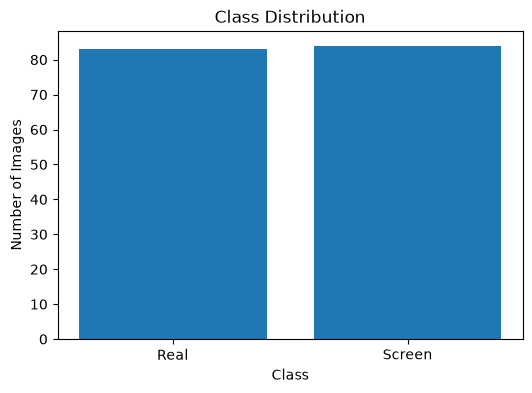

In [25]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Real","Screen"],
    [total_real,total_screen]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

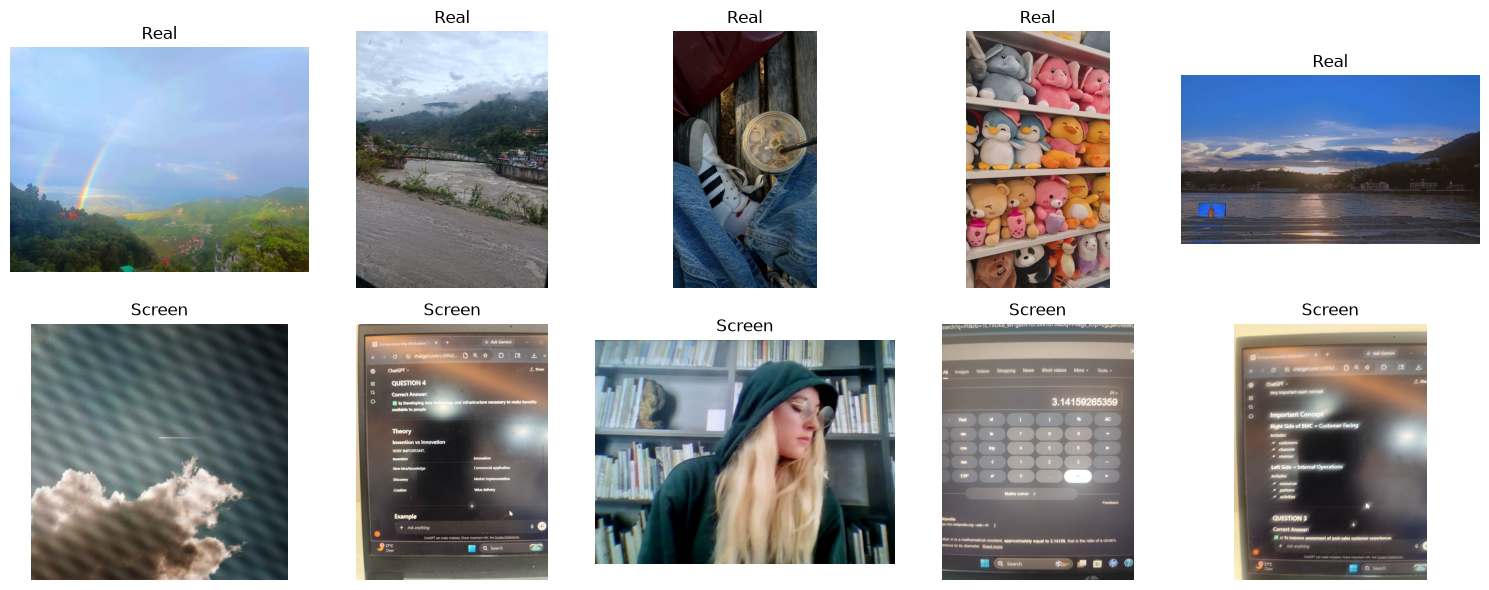

In [26]:
fig, axes = plt.subplots(2,5,figsize=(15,6))

real_images = random.sample(os.listdir(train_real),5)
screen_images = random.sample(os.listdir(train_screen),5)

for i,img_name in enumerate(real_images):

    img = Image.open(os.path.join(train_real,img_name))

    axes[0,i].imshow(img)
    axes[0,i].set_title("Real")
    axes[0,i].axis("off")

for i,img_name in enumerate(screen_images):

    img = Image.open(os.path.join(train_screen,img_name))

    axes[1,i].imshow(img)
    axes[1,i].set_title("Screen")
    axes[1,i].axis("off")

plt.tight_layout()

plt.show()

In [27]:
sizes=[]

folders=[
    train_real,
    train_screen,
    val_real,
    val_screen,
    test_real,
    test_screen
]

for folder in folders:

    for image in os.listdir(folder):

        img=Image.open(os.path.join(folder,image))

        sizes.append(img.size)

Counter(sizes).most_common(10)

[((1600, 1200), 37),
 ((640, 480), 28),
 ((1200, 1600), 27),
 ((800, 800), 15),
 ((736, 981), 7),
 ((736, 1308), 7),
 ((675, 1200), 4),
 ((610, 1356), 4),
 ((736, 1104), 3),
 ((5405, 8103), 2)]

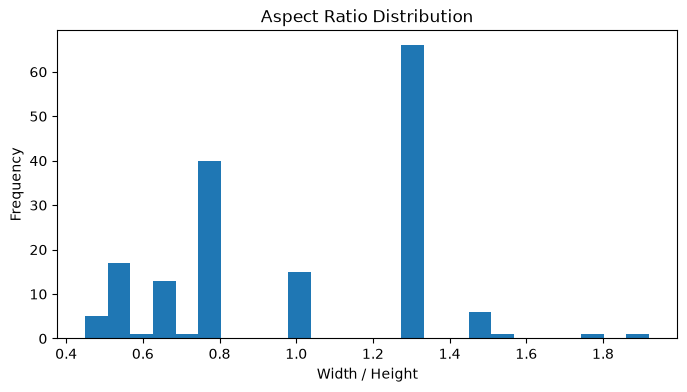

In [28]:
aspect_ratios=[]

for w,h in sizes:

    aspect_ratios.append(round(w/h,2))

plt.figure(figsize=(8,4))

plt.hist(aspect_ratios,bins=25)

plt.title("Aspect Ratio Distribution")

plt.xlabel("Width / Height")

plt.ylabel("Frequency")

plt.show()

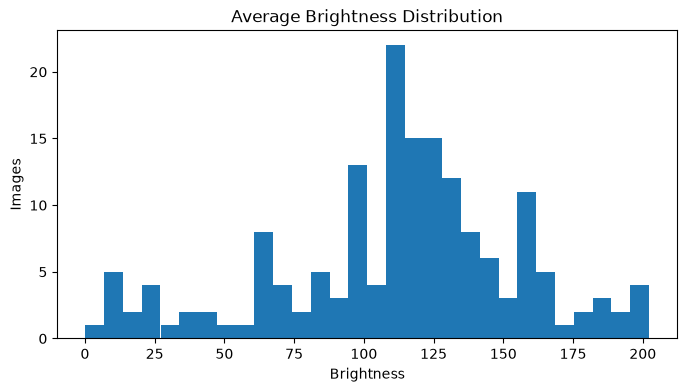

In [29]:
brightness=[]

for folder in folders:

    for image in os.listdir(folder):

        img=Image.open(os.path.join(folder,image)).convert("L")

        brightness.append(np.array(img).mean())

plt.figure(figsize=(8,4))

plt.hist(brightness,bins=30)

plt.title("Average Brightness Distribution")

plt.xlabel("Brightness")

plt.ylabel("Images")

plt.show()

In [30]:
corrupted=[]

for folder in folders:

    for image in os.listdir(folder):

        try:

            Image.open(os.path.join(folder,image)).verify()

        except:

            corrupted.append(image)

print("Total Corrupted Images :",len(corrupted))

if len(corrupted)==0:

    print("✅ No corrupted images found.")

else:

    print(corrupted)

Total Corrupted Images : 0
✅ No corrupted images found.


In [31]:
sizes_df=pd.DataFrame(
    sizes,
    columns=["Width","Height"]
)

sizes_df.describe()

,Width,Height
count,167.000000,167.000000
mean,1469.059880,1572.149701
std,1260.330286,1433.277652
min,610.000000,480.000000
25%,736.000000,800.000000
50%,1200.000000,1200.000000
75%,1600.000000,1600.000000
max,6016.000000,8103.000000


# Conclusion

### Observations

- The dataset is well balanced between both classes.
- No corrupted images were detected.
- Images contain multiple resolutions.
- Different aspect ratios are present.
- Brightness varies across samples, increasing robustness.

The dataset is ready for training using transfer learning with ResNet18.